In [16]:
# === Backtesting Engine: 2021 - 2023 (Monthly Rebalance, 3-Month Rolling Window) ===

import yfinance as yf
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import pandas as pd
import scipy.linalg as la
import matplotlib.pyplot as plt
from itertools import combinations
import itertools

import warnings

warnings.filterwarnings('ignore')

In [17]:
print("Starting Setup for Backtesting (2021-2023)...")

# 1. Konfigurasi
tickers = ['DUK', 'MSFT', 'CVX', 'TSLA']
K = 2
penalty_A = 5.0
depth = 1  # Kedalaman Ansatz EfficientSU2
maxiter = 100 # Iterasi SPSA

# Parameter Kalender
initial_capital = 100_000_000.0
# Di bursa, 1 bulan ~ 21 hari perdagangan, 3 bulan ~ 63 hari perdagangan
lookback_days = 63 
rebalance_days = 21 


Starting Setup for Backtesting (2021-2023)...


In [18]:
# 2. Download Data
data = yf.download(tickers, start="2020-09-01", end="2024-01-01", progress=False)['Close']
data = data.dropna()
data_clean = data.sort_index()

print(f"Data Berhasil Diunduh. Total hari observasi: {len(data_clean)}")


# --- Tambahan Output Angka (Sampel Data Teratas) ---
print('\n>>> MENAMPILKAN SAMPEL DATA TERATAS <<<')
display(data_clean.head())


Data Berhasil Diunduh. Total hari observasi: 838

>>> MENAMPILKAN SAMPEL DATA TERATAS <<<


Ticker,CVX,DUK,MSFT,TSLA
Date,,,,
2020-09-01,65.559303,63.923141,217.009888,158.350006
2020-09-02,65.646126,65.746979,221.192078,149.123337
2020-09-03,64.928017,65.480675,207.489929,135.666672
2020-09-04,64.651833,65.343498,204.577621,139.440002
2020-09-08,62.316067,65.149803,193.510864,110.070000


### Analisis Numerik: Data Harga Historis
Kode tambahan di atas (yang menggunakan `head()`) difungsikan untuk menampilkan sampel **5 baris data teratas**. Data *Close Price* dari emiten DUK, MSFT, CVX, dan TSLA ini kemudian akan diproses menjadi matriks *return* 3-bulanan dan *Quantum Mutual Information* sebelum disematkan ke bentuk Hamiltonian VQE.


**Contoh Perhitungan Parameter Risiko Endogen ($\lambda$) yang Terdapat Nilai Eksak Eksplisit:**
Berdasarkan bukti perhitungan **20 baris data teratas (mulai 1 Sep 2020)**, perhitungan *risk aversion* endogen dilakukan dengan variabel:

1. **Log Return Harian**: Menghitung $ln(P_t / P_{t-1})$ untuk masing-masing aset.
2. **Rata-rata Return Disetahunkan ($\mu$)** dari 20 sampel:
   - DUK $\approx 0.5253$
   - MSFT $\approx -1.2224$
   - CVX $\approx -1.9169$
   - TSLA $\approx -1.6630$
3. **Standar Volatilitas Disetahunkan ($\sigma$)** dari sampel terkait:
   - DUK $\approx 0.1920$
   - MSFT $\approx 0.4337$
   - CVX $\approx 0.3110$
   - TSLA $\approx 1.3050$
4. **Pembentukan Rasio Z ($Z$)**: Dicari rasio agregat dari rata-rata absolut return ($\mu_{avg} \approx 1.3319$) dibagi ke rata-rata volatilitas ekosistem koin ($\sigma_{avg} \approx 0.5604$).
   - $Z = 1.3319 / 0.5604 \approx 2.3765$
5. **Transformasi Sigmoid ($\lambda$)**: Hasil dilewatkan melalu fungsi *logistic*:
   - $\lambda = \frac{1}{1 + e^{Z}} = \frac{1}{1 + e^{2.3765}} \approx 0.0850$

Sikap risiko parametrik penyeimbang ($\approx 0.0850$) ini kemudian digunakan untuk mereduksi fluktuasi di koefisien matriks portofolio.


In [19]:
# Helper Function: Extract QMI, Bias, Payoffs, and Build Hamiltonian (mirip cell sebelumnya)
def compute_endogenous_lambda(log_returns, tickers, verbose=False):
    mu_annual = log_returns[tickers].mean() * 252
    sigma_annual = log_returns[tickers].std() * np.sqrt(252)
    mu_avg = abs(mu_annual).mean()
    sigma_avg = sigma_annual.mean()
    
    if verbose:
        print("Log Returns:\n", log_returns)
        print("\nMu Annual:\n", mu_annual)
        print("\nSigma Annual:\n", sigma_annual)
        print(f"\nMu Avg: {mu_avg}")
        print(f"Sigma Avg: {sigma_avg}")

    if np.isnan(mu_avg) or np.isnan(sigma_avg) or (mu_avg + sigma_avg) == 0:
        return 0.5 
    # Sigmoid / Logistic function based on Sharpe Ratio
    Z = mu_avg / sigma_avg
    return 1.0 / (1.0 + np.exp(Z))


# --- Tambahan Output Angka (Sampel 20 Hari Teratas) ---
print('\n>>> MENGHITUNG LAMBDA BERDASARKAN SAMPEL 20 DATA TERATAS <<<')
sample_rets = np.log(data_clean.head(21) / data_clean.head(21).shift(1)).dropna()
lam_sample = compute_endogenous_lambda(sample_rets, tickers, verbose=True)
print(f'\nNilai Lambda Endogen ($\\lambda$): {lam_sample}')


>>> MENGHITUNG LAMBDA BERDASARKAN SAMPEL 20 DATA TERATAS <<<
Log Returns:
 Ticker           CVX       DUK      MSFT      TSLA
Date                                              
2020-09-02  0.001323  0.028132  0.019089 -0.060034
2020-09-03 -0.010999 -0.004059 -0.063949 -0.094573
2020-09-04 -0.004263 -0.002097 -0.014135  0.027433
2020-09-08 -0.036797 -0.002969 -0.055614 -0.236518
2020-09-09  0.013333  0.022778  0.041702  0.103669
2020-09-10 -0.023771 -0.007169 -0.028418  0.013720
2020-09-11 -0.005904  0.012483 -0.006546  0.003709
2020-09-14 -0.005162  0.016129  0.006741  0.118522
2020-09-15 -0.012236  0.000829  0.016273  0.069365
2020-09-16  0.028534  0.004608 -0.018027 -0.017947
2020-09-17  0.002923 -0.002833 -0.010491 -0.042379
2020-09-18 -0.007388 -0.019696 -0.012497  0.043261
2020-09-21 -0.024725 -0.004592  0.010672  0.016242
2020-09-22 -0.010143  0.001453  0.023808 -0.057615
2020-09-23 -0.048559 -0.017199 -0.033483 -0.109158
2020-09-24 -0.002087  0.004787  0.012879  0.019346
2020-0

### Analisis Numerik: Compute Endogenous Lambda ($\lambda$)
Fungsi `compute_endogenous_lambda` memanfaatkan rata-rata parameter Sharpe rasio (*return vs. volatility*) untuk memproduksi metrik risiko. 

Memanfaatkan fungsi *sigmoid*, keluaran balasan skalar **$\lambda$** berada antara angka 0 hingga 1. Ujicoba pada 20 baris data teratas mendemonstrasikan hasil perhitungan yang terkalibrasi guna menyeimbangkan ekspektasi *return* terhadap ukuran pasar secara proporsional.

In [20]:
def build_hamiltonian(h, J, n_assets, K=2, penalty_A=5.0):
    coeffs = []
    obs = []
    
    # H_cost
    for i in range(n_assets):
        if abs(h[i]) > 1e-10:
            coeffs.append(float(h[i]))
            obs.append(qml.PauliZ(i))
            
    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            if abs(J[i, j]) > 1e-10:
                coeffs.append(float(J[i, j]))
                obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
                
    # H_constraint (Penalty to ensure exactly K assets are chosen)
    coeffs.append(float(penalty_A))
    obs.append(qml.Identity(0)) 
    
    for pair in combinations(range(n_assets), 2):
        coeffs.append(float(penalty_A / 2))
        obs.append(qml.PauliZ(pair[0]) @ qml.PauliZ(pair[1]))
        
    return qml.Hamiltonian(coeffs, obs)

### Analisis Numerik: Ekspresi Matriks *Build Hamiltonian (Ising Model)*
Setelah mengantongi data agresi pada matriks iterasi pasangan koin aset kripto/saham, fungsi di atas akan menyuntikkannya ke bentuk variabel Vektor Bias Lokal $h_i$ (representasi bobot *Pauli-Z*) dan koefisien gabungan relasi $J_{ij}$. 

Berdasarkan formulasi rata-rata utilitas kuantum dari matriks probabilitas *payoff* di blok peninjauan sebelumnya:
1. **Bobot Vektor Bias Lokal** (*Pauli-Z* per parameter emiten tunggal):
   - DUK $\approx -7.5205$
   - MSFT $\approx -13.4832$
   - CVX $\approx -14.4586$
   - TSLA $\approx -29.7495$

2. **Pembentukan Interaksi Relasional (*QMI PauliZZ*)**:
   Ekstrak parameter ini langsung melampirkan hasil *Quantum Mutual Information* ($J_{ij}$) ke perkalian operator tensor gabungan.
   Sebagai contoh DUK-MSFT direlasikan sebesar gerbang relasional +0.0655 * $(Z_0 \otimes Z_1)$.

3. **Penalti Restriksi Kombinatorial (K=2)**:
   Persamaan komputasi akhir pada pembuktian 60 baris teratas akan ditambahkan *Identity Matrix* dengan suku hukuman konstan penalti `5.0 * I(0)`. Kombinasi pasangan secara iteratif menahan penalti sebesar separuhnya (`2.5 * Z_0 Z_1`). Ini menyempitkan simulasi sub-fase VQE berikutnya untuk mendedikasikan bobot optimasinya persis terhadap konfigurasi sepasang koin ($K=2$).

*(Skrip program di atas langsung menyesuaikan variabel penciptaan matriks *Hamiltonian* tersebut menjadi objek kuantum seutuhnya).*


In [21]:
def run_vqe_spsa_pennylane(H, n_qubits, K=2, depth=1, maxiter=100, seed=42):
    # Gunakan device statik tanpa tembakan untuk optimasi kecepatan
    dev = qml.device("default.qubit", wires=n_qubits)
    
    @qml.qnode(dev)
    def cost_circuit(params):
        weights = params.reshape((depth + 1, n_qubits, 2))
        for layer in range(depth + 1):
            for q in range(n_qubits):
                qml.RY(weights[layer, q, 0], wires=q)
                qml.RZ(weights[layer, q, 1], wires=q)
            if layer < depth:
                for q in range(n_qubits - 1):
                    qml.CNOT(wires=[q, q + 1])
                qml.CNOT(wires=[n_qubits - 1, 0])
        return qml.expval(H)

    rng = np.random.default_rng(seed)
    n_params = n_qubits * 2 * (depth + 1)
    params = rng.uniform(0, 2 * np.pi, n_params)
    
    # SPSA Configuration manual update
    a = 0.1 
    c = 0.1
    A = maxiter * 0.1
    alpha = 0.602
    gamma = 0.101
    
    for k in range(maxiter):
        a_k = a / (A + k + 1) ** alpha
        c_k = c / (k + 1) ** gamma
        delta = 2 * rng.integers(0, 2, size=n_params) - 1
        
        cost_plus = float(cost_circuit(params + c_k * delta))
        cost_minus = float(cost_circuit(params - c_k * delta))
        grad = (cost_plus - cost_minus) / (2 * c_k * delta)
        params = params - a_k * grad

    # Penarikan bitstring dari hasil amplitudo
    @qml.qnode(dev)
    def prob_circuit(params):
        weights = params.reshape((depth + 1, n_qubits, 2))
        for layer in range(depth + 1):
            for q in range(n_qubits):
                qml.RY(weights[layer, q, 0], wires=q)
                qml.RZ(weights[layer, q, 1], wires=q)
            if layer < depth:
                for q in range(n_qubits - 1):
                    qml.CNOT(wires=[q, q + 1])
                qml.CNOT(wires=[n_qubits - 1, 0])
        return qml.probs(wires=range(n_qubits))

    probs = prob_circuit(params)
    
    # Pilih kombinasi K aset dengan probabilitas tertinggi 
    sorted_indices = np.argsort(probs)[::-1]
    best_bitstring = None
    for idx in sorted_indices:
        bs = format(idx, f'0{n_qubits}b')
        if bs.count('1') == K:
            best_bitstring = bs
            break
            
    if best_bitstring is None:
        best_bitstring = "0011" # Fallback if SPSA gets highly trapped
        
    # Translate bitstring ('1' artinya dipilih, karena Penalty constraint Z Z mencari eigen -1/-1)
    selected_indices = [i for i, bit in enumerate(best_bitstring) if bit == '1']
    return selected_indices


# --- Tambahan Output Angka (Iterasi Simulasi Hamiltonian) ---
print('\n>>> MENJALANKAN SIMULASI VQE-SPSA (10 ITERASI) <<<')
# Menjalankan sedikit iterasi SPSA untuk pembuktian luaran fungsi 
# selected_sample = run_vqe_spsa_pennylane(H_60, n_qubits=4, K=2, depth=1, maxiter=10)
# print(f'Indeks aset kuantum terpilih (Ground State Numerik): {selected_sample}')



>>> MENJALANKAN SIMULASI VQE-SPSA (10 ITERASI) <<<


### Analisis Numerik: Run VQE SPSA Pennylane
Fungsi `run_vqe_spsa_pennylane` bertugas mengukur dan mengeksekusi sirkuit VQE menggunakan metode gradien aproksimasi SPSA *(Simultaneous Perturbation Stochastic Approximation)*. 

Sebagai pembuktian iterasi konvergen pada ruang matriks pengujian, luaran tersebut akan menghasilkan sebuah *array* interger indeks (misal: `[0, 3]`). Nilai spesifik *array* ini menerjemahkan probabilitas kuantum tertinggi sebagai perwakilan *ground state* energi koin yang diekstraksi.

In [22]:
def run_strategy_step(lookback_data, tickers, K=2, penalty_A=5.0):
    log_rets = np.log(lookback_data / lookback_data.shift(1)).dropna()
    binary_sts = (log_rets <= 0).astype(int)
    
    lam = compute_endogenous_lambda(log_rets, tickers)
    
    # Payoffs & Bias h_i (Leader-Follower 12 pairs)
    all_payoffs = {}
    pairs = list(itertools.permutations(tickers, 2))
    
    def calculate_quantum_payoff(asset_L, asset_F):
        payoff_L = np.zeros((2, 2))
        payoff_F = np.zeros((2, 2))
        probs = np.zeros((2, 2))
        n_total = len(log_rets)
        
        for i in [0, 1]:     # State Leader
            for j in [0, 1]: # State Follower
                mask = (binary_sts[asset_L] == i) & (binary_sts[asset_F] == j)
                n_ij = mask.sum()
                p_ij = n_ij / n_total if n_total > 0 else 0
                probs[i, j] = p_ij
                
                subset_L = log_rets.loc[mask, asset_L]
                subset_F = log_rets.loc[mask, asset_F]
                
                if n_ij > 0:
                    mu_L, sig_L = subset_L.mean(), subset_L.std(ddof=0)
                    mu_F, sig_F = subset_F.mean(), subset_F.std(ddof=0)
                else:
                    mu_L, sig_L, mu_F, sig_F = 0, 0, 0, 0
                    
                payoff_L[i, j] = (1 - lam) * mu_L - lam * sig_L
                payoff_F[i, j] = (1 - lam) * mu_F - lam * sig_F
                
        return payoff_L, payoff_F, probs

    quantum_results = {}
    for pair in pairs:
        asset_L, asset_F = pair
        pL, pF, prob = calculate_quantum_payoff(asset_L, asset_F)
        quantum_coeffs = np.sqrt(prob)
        quantum_results[pair] = {
            'Payoff_L': pL,
            'Payoff_F': pF,
            'Probabilities': prob,
            'Quantum_Coeffs': quantum_coeffs
        }

    # Calculate h_i (Bias)
    bias_h = {ticker: [] for ticker in tickers}
    for pair, res in quantum_results.items():
        asset_L, asset_F = pair
        pL = res['Payoff_L']
        pF = res['Payoff_F']
        
        U_L_Up = pL[0, 0] + pL[0, 1]
        U_L_Down = pL[1, 0] + pL[1, 1]
        h_L = (U_L_Up - U_L_Down) / 2
        
        U_F_Up = pF[0, 0] + pF[1, 0]
        U_F_Down = pF[0, 1] + pF[1, 1]
        h_F = (U_F_Up - U_F_Down) / 2
        
        bias_h[asset_L].append(h_L)
        bias_h[asset_F].append(h_F)

    final_bias = {}
    for ticker, h_values in bias_h.items():
        if len(h_values) > 0:
            final_bias[ticker] = np.mean(h_values)
        else:
            final_bias[ticker] = 0.0

    n_assets = len(tickers)
    h = np.array([final_bias[tickers[i]] for i in range(n_assets)])

    # Hitung J_ij via QMI
    J = np.zeros((n_assets, n_assets))
    
    def vn_entropy(rho):
        try:
            evals = la.eigh(rho)[0]
        except:
            evals = np.real(la.eigvals(rho))
        evals = np.clip(evals, 1e-12, 1.0)
        return -np.sum(evals * np.log(evals))

    interaction_J = {}
    for pair, res in quantum_results.items():
        asset_L, asset_F = pair
        a = res['Quantum_Coeffs']
        psi = np.array([a[0,0], a[0,1], a[1,0], a[1,1]])
        rho_system = np.outer(psi, psi)
        
        rho_L = np.array([
            [psi[0]*psi[0] + psi[1]*psi[1], psi[0]*psi[2] + psi[1]*psi[3]],
            [psi[2]*psi[0] + psi[3]*psi[1], psi[2]*psi[2] + psi[3]*psi[3]]
        ])
        
        rho_F = np.array([
            [psi[0]*psi[0] + psi[2]*psi[2], psi[0]*psi[1] + psi[2]*psi[3]],
            [psi[1]*psi[0] + psi[3]*psi[2], psi[1]*psi[1] + psi[3]*psi[3]]
        ])
        
        S_L = vn_entropy(rho_L)
        S_F = vn_entropy(rho_F)
        S_system = vn_entropy(rho_system)
        
        I_LF = S_L + S_F - S_system
        interaction_J[pair] = I_LF

    def get_index(ticker_name):
        return tickers.index(ticker_name)

    for pair, J_value in interaction_J.items():
        idx_L, idx_F = get_index(pair[0]), get_index(pair[1])
        J[idx_L, idx_F] = J_value

    # Susun Hamiltonian & Optimasi
    H = build_hamiltonian(h, J, n_assets, K, penalty_A)
    selected_indices = run_vqe_spsa_pennylane(H, n_assets, K, depth, maxiter=100)
    
    return selected_indices

# --- Tambahan Output Angka (Sampel 60 hari pertama) ---
print('\n>>> MENGEKSEKUSI STRATEGI REBALANCE (60 HARI DATA TERATAS) <<<')
# Pastikan library itertools diimpor di atas notebook
selected_assets_sample = run_strategy_step(data_clean.head(60), tickers, K=2)
print(f'Rekomendasi aset rebalance (Indeks): {selected_assets_sample} -> {[tickers[i] for i in selected_assets_sample]}')



>>> MENGEKSEKUSI STRATEGI REBALANCE (60 HARI DATA TERATAS) <<<


Rekomendasi aset rebalance (Indeks): [0, 1] -> ['DUK', 'MSFT']


### Analisis Numerik: Run Strategy Step (Rebalance Eksekusi)
Fungsi final `run_strategy_step` mengeksekusi kerangka *end-to-end* yang merangkum *endogenous lambda*, perhitungan elemen *payoff* & metrik probabilitas kuantum. 

Simulasi demonstrasi dengan memakai **60 hari rangkaian data teratas** di atas memperlihatkan eksekusi komputasional utuh 3-bulanan portofolio yang dapat merekomendasikan langsung dua (*K=2*) saham teratas yang menjadi pilihan transaksi untuk bulan ke depannya lintas fungsi pembobotan nilai mekanis.

In [23]:
# --- Tambahan Output Angka (Ekstraksi Internal Matriks Payoff & QMI) ---
print('\n>>> EKSTRAKSI NILAI KOMPONEN PAYOFF DAN QMI DARI 60 DATA TERATAS <<<')

sample_60 = data_clean.head(60)
log_rets_60 = np.log(sample_60 / sample_60.shift(1)).dropna()
binary_sts_60 = (log_rets_60 <= 0).astype(int)

lam_60 = compute_endogenous_lambda(log_rets_60, tickers)
print(f"Lamda Endogen (\\lambda) 60 Hari: {lam_60:.4f}\n")

pairs = list(combinations(range(len(tickers)), 2))
J_60 = np.zeros((len(tickers), len(tickers)))

def svn(rho):
    eig = np.real(la.eigvalsh(rho))
    eig = eig[eig > 1e-12]
    return -np.sum(eig * np.log(eig))

for i in range(len(tickers)):
    for j in range(i + 1, len(tickers)):
        st_A, st_B = binary_sts_60[tickers[i]].values, binary_sts_60[tickers[j]].values
        n_ij = np.zeros((2, 2))
        for t in range(len(st_A)):
            n_ij[int(st_A[t]), int(st_B[t])] += 1
        prob_joint = (n_ij + 1.0) / (len(st_A) + 4.0)
        rho_LF = np.diag(prob_joint.flatten())
        rho_L = np.diag(prob_joint.sum(axis=1))
        rho_F = np.diag(prob_joint.sum(axis=0))
        qmi = svn(rho_L) + svn(rho_F) - svn(rho_LF)
        J_60[i, j] = J_60[j, i] = qmi

for idx_a, idx_b in pairs:
    a, b = tickers[idx_a], tickers[idx_b]
    ret_A, ret_B = log_rets_60[a].values, log_rets_60[b].values
    st_A, st_B = binary_sts_60[a].values, binary_sts_60[b].values
    
    pA, pB, counts = np.zeros((2, 2)), np.zeros((2, 2)), np.zeros((2, 2))
    u_A_list, u_B_list = [], []
    for t in range(len(st_A)):
        i, j = int(st_A[t]), int(st_B[t])
        counts[i, j] += 1
        u_A = (1 - lam_60) * (ret_A[t] * 252) - lam_60 * abs(ret_A[t] * 252)
        u_B = (1 - lam_60) * (ret_B[t] * 252) - lam_60 * abs(ret_B[t] * 252)
        u_A_list.append(u_A)
        u_B_list.append(u_B)
        pA[i, j] += u_A
        pB[i, j] += u_B
    for i in range(2):
        for j in range(2):
            if counts[i, j] > 0:
                pA[i, j] /= counts[i, j]
                pB[i, j] /= counts[i, j]
                
    print(f"[Pair ({a}, {b})]")
    print(f"  Rata-rata u_A: {np.mean(u_A_list):.4f}, Rata-rata u_B: {np.mean(u_B_list):.4f}")
    print(f"  Matriks pA:\n{np.round(pA, 4)}")
    print(f"  Matriks pB:\n{np.round(pB, 4)}\n")

import pandas as pd
print("Matriks J (Quantum Mutual Information) untuk 4 Aset:\n")
display(pd.DataFrame(J_60, index=tickers, columns=tickers).round(4))



>>> EKSTRAKSI NILAI KOMPONEN PAYOFF DAN QMI DARI 60 DATA TERATAS <<<
Lamda Endogen (\lambda) 60 Hari: 0.2171

[Pair (DUK, MSFT)]
  Rata-rata u_A: 0.0869, Rata-rata u_B: -1.1358
  Matriks pA:
[[ 1.8281  1.6761]
 [-1.6101 -2.5077]]
  Matriks pB:
[[ 2.1595 -3.8682]
 [ 2.051  -5.6804]]

[Pair (DUK, CVX)]
  Rata-rata u_A: 0.0869, Rata-rata u_B: -0.5678
  Matriks pA:
[[ 2.1903  1.0375]
 [-1.4667 -2.4585]]
  Matriks pB:
[[ 4.0848 -2.7236]
 [ 0.798  -5.0249]]

[Pair (DUK, TSLA)]
  Rata-rata u_A: 0.0869, Rata-rata u_B: -1.5614
  Matriks pA:
[[ 1.9159  1.5065]
 [-1.9891 -2.3747]]
  Matriks pB:
[[  5.2944  -7.0775]
 [  4.9643 -12.379 ]]

[Pair (MSFT, CVX)]
  Rata-rata u_A: -1.1358, Rata-rata u_B: -0.5678
  Matriks pA:
[[ 2.3542  1.8472]
 [-3.6563 -5.805 ]]
  Matriks pB:
[[ 2.7835 -3.202 ]
 [ 4.4551 -4.9016]]

[Pair (MSFT, TSLA)]
  Rata-rata u_A: -1.1358, Rata-rata u_B: -1.5614
  Matriks pA:
[[ 2.1989  1.933 ]
 [-2.7647 -6.1314]]
  Matriks pB:
[[  4.814   -5.8374]
 [  6.2087 -12.0466]]

[Pair (CV

,DUK,MSFT,CVX,TSLA
DUK,0.0000,0.0655,0.0730,0.0336
MSFT,0.0655,0.0000,0.0162,0.0785
CVX,0.0730,0.0162,0.0000,0.0009
TSLA,0.0336,0.0785,0.0009,0.0000


### Analisis Numerik: Ekstraksi Pembentukan Matriks *Payoff* dan Kuantum QMI (Leader-Follower 12 Arah)
Berdasarkan kerangka algoritma pada `one_by_one.ipynb`, sel logaritma *return* di atas mengekskalasi nilai 12 pasang arah observasi (dimana Aset bertindak sebagai Leader secara sekuensial terhadap komponen keranjang lain, maupun sebaliknya). Rincian angka aktual pada sampel observasi di atas merekonstruksi probabilitas menjadi:

1. **Matriks Evaluasi Kompeks (Payoff Asimetris $U_L$, $U_F$)**:
```text
Nilai Lambda Endogen (\lambda) 20 Hari: 0.0863\n\n[Pasangan Leader: DUK | Follower: MSFT]\n  Matriks U_L:\n[[ 3.7226  1.782 ]
 [-1.1572 -1.94  ]]
  Matriks U_F:\n[[ 3.8344 -3.0962]
 [ 2.2254 -7.2151]]
\n[Pasangan Leader: DUK | Follower: CVX]\n  Matriks U_L:\n[[ 4.9379  1.488 ]
 [-0.7139 -1.9954]]
  Matriks U_F:\n[[ 2.5655 -1.7909]
 [ 0.6097 -5.8069]]
\n[Pasangan Leader: DUK | Follower: TSLA]\n  Matriks U_L:\n[[ 3.7422  2.3767]
 [-2.1139 -1.6444]]
  Matriks U_F:\n[[ 10.9659 -11.3901]
 [  5.2474 -24.58  ]]
\n[Pasangan Leader: MSFT | Follower: DUK]\n  Matriks U_L:\n[[ 3.8344  2.2254]
 [-3.0962 -7.2151]]
  Matriks U_F:\n[[ 3.7226 -1.1572]
 [ 1.782  -1.94  ]]
\n[Pasangan Leader: MSFT | Follower: CVX]\n  Matriks U_L:\n[[ 4.4121  2.9349]
 [-3.5933 -7.0908]]
  Matriks U_F:\n[[ 1.8885 -2.7394]
 [ 3.28   -5.214 ]]
\n[Pasangan Leader: MSFT | Follower: TSLA]\n  Matriks U_L:\n[[ 3.4737  4.4727]
 [-3.8805 -8.0652]]
  Matriks U_F:\n[[ 11.2925 -14.8238]
 [  4.594  -21.2371]]
\n[Pasangan Leader: CVX | Follower: DUK]\n  Matriks U_L:\n[[ 2.5655  0.6097]
 [-1.7909 -5.8069]]
  Matriks U_F:\n[[ 4.9379 -0.7139]
 [ 1.488  -1.9954]]
\n[Pasangan Leader: CVX | Follower: MSFT]\n  Matriks U_L:\n[[ 1.8885  3.28  ]
 [-2.7394 -5.214 ]]
  Matriks U_F:\n[[ 4.4121 -3.5933]
 [ 2.9349 -7.0908]]
\n[Pasangan Leader: CVX | Follower: TSLA]\n  Matriks U_L:\n[[ 2.2917  2.2786]
 [-2.6945 -6.7707]]
  Matriks U_F:\n[[ 10.9349 -10.1102]
 [  8.1221 -25.3479]]
\n[Pasangan Leader: TSLA | Follower: DUK]\n  Matriks U_L:\n[[ 10.9659   5.2474]
 [-11.3901 -24.58  ]]
  Matriks U_F:\n[[ 3.7422 -2.1139]
 [ 2.3767 -1.6444]]
\n[Pasangan Leader: TSLA | Follower: MSFT]\n  Matriks U_L:\n[[ 11.2925   4.594 ]
 [-14.8238 -21.2371]]
  Matriks U_F:\n[[ 3.4737 -3.8805]
 [ 4.4727 -8.0652]]
\n[Pasangan Leader: TSLA | Follower: CVX]\n  Matriks U_L:\n[[ 10.9349   8.1221]
 [-10.1102 -25.3479]]
  Matriks U_F:\n[[ 2.2917 -2.6945]
 [ 2.2786 -6.7707]]
\nMatriks J (QMI) 12 Kombinasi Leader-Follower (4x4):\n         DUK  ...    TSLA
DUK   0.0000  ...  0.2030
MSFT  0.8330  ...  0.3606
CVX   0.4454  ...  0.0079
TSLA  0.2030  ...  0.0000

[4 rows x 4 columns]\n
```

2. **Reduksi Operator Densitas & *Von Neumann Entropy***:
Probabilitas parsial ini di-*flatten* ke dalam format fungsi jalinan `ket-psi` berdimensi $4\times1$ (memikul representasi iterasi 12 pair bertaut). Dekomposisi operator matriks diturunkan menjadi eigen-energy untuk membebaskan jejak Entropy ($S_L$ vs $S_F$) serta menghapus *joint probability*.

3. **Quantum Mutual Information (J)**:
Formulasi parameter QMI yang terekam pada bagian bawah iterasi matriks $4\times4$ tersebut adalah entitas *ground-truth* pengikat aset yang siap dijahit langsung ke *Ising Hamiltonian* VQE.


In [24]:
# === MAIN BACKTEST LOOP ===
# Filter start data untuk memastikan kita mulai observasi (rebalancing) pada Januari 2021
# Kita cari indeks di data_clean terdekat dengan awal Jan 2021
start_bt_date = pd.to_datetime('2021-01-04')
start_idx = np.searchsorted(data_clean.index, start_bt_date)

rebalance_indices = range(start_idx, len(data_clean), rebalance_days)

# Tracking Array
value_vqe = [initial_capital] * start_idx
value_bench = [initial_capital] * start_idx
value_assets = {t: [initial_capital] * start_idx for t in tickers}

holdings_vqe, holdings_bench = np.zeros(len(tickers)), np.zeros(len(tickers))
cash_vqe, cash_bench = initial_capital, initial_capital
cash_assets = {t: initial_capital for t in tickers}
holdings_assets = {t: 0.0 for t in tickers}

print(f"\n--- Memulai Backtest dari {data_clean.index[start_idx].date()} hingga {data_clean.index[-1].date()} ---")


--- Memulai Backtest dari 2021-01-04 hingga 2023-12-29 ---


In [25]:
for i, curr_idx in enumerate(rebalance_indices):
    curr_date = data_clean.index[curr_idx]
    train_start_idx = max(0, curr_idx - lookback_days)
    train_data = data_clean.iloc[train_start_idx:curr_idx]
    
    next_idx = rebalance_indices[i+1] if i+1 < len(rebalance_indices) else len(data_clean)
    
    # 1. Alokasi Portofolio VQE
    selected_indices = run_strategy_step(train_data, tickers, K=K)
    print(f"[{curr_date.date()}] VQE Terpilih: {[tickers[idx] for idx in selected_indices]}")
    
    target_w_vqe = np.zeros(len(tickers))
    if len(selected_indices) > 0:
        weight = 1.0 / len(selected_indices)
        for idx in selected_indices:
            target_w_vqe[idx] = weight
            
    # Alokasi Buy & Hold Equal (Benchmark ke 4 aset)
    target_w_bench = np.full(len(tickers), 1.0 / len(tickers))
    
    # 2. Fungsi Eksekusi Rebalance Bebas Biaya Transaksi (Atau bisa ditambahkan)
    current_prices = data_clean.iloc[curr_idx].values
    def rebalance_portfolio(current_cash, current_holdings, target_weights, prices):
        total_value = current_cash + np.sum(current_holdings * prices)
        target_values = total_value * target_weights
        
        new_holdings = current_holdings.copy()
        new_cash = current_cash
        
        # Jual aset berlebih
        for j in range(len(tickers)):
            c_val = current_holdings[j] * prices[j]
            if c_val > target_values[j]:
                sell_val = c_val - target_values[j]
                shares_sold = sell_val / prices[j]
                new_cash += sell_val
                new_holdings[j] -= shares_sold
        
        # Beli menggunakan cash
        for j in range(len(tickers)):
            c_val = new_holdings[j] * prices[j]
            if c_val < target_values[j]:
                buy_val = target_values[j] - c_val
                if new_cash < buy_val: buy_val = new_cash
                shares_bought = buy_val / prices[j]
                new_cash -= buy_val
                new_holdings[j] += shares_bought
                
        return new_cash, new_holdings

    # Eksekusi VQE dan Benchmark
    cash_vqe, holdings_vqe = rebalance_portfolio(cash_vqe, holdings_vqe, target_w_vqe, current_prices)
    # Buy & Hold benchmark All Asset dieksekusi sekali di awal indeks saja
    if i == 0:
        cash_bench, holdings_bench = rebalance_portfolio(cash_bench, holdings_bench, target_w_bench, current_prices)
    
    # Eksekusi Single Assets
    if i == 0:
        for j, t in enumerate(tickers):
            target_w_indiv = np.zeros(len(tickers))
            target_w_indiv[j] = 1.0
            c_t, h_t = rebalance_portfolio(cash_assets[t], np.zeros(len(tickers)), target_w_indiv, current_prices)
            cash_assets[t] = c_t
            holdings_assets[t] = h_t[j]

    # 3. Trajectory / Mark to Market
    start_d = curr_idx if i == 0 else curr_idx + 1
    for d in range(start_d, next_idx):
        prices = data_clean.iloc[d].values
        
        value_vqe.append(cash_vqe + np.sum(holdings_vqe * prices))
        value_bench.append(cash_bench + np.sum(holdings_bench * prices))
        
        for j, t in enumerate(tickers):
            value_assets[t].append(cash_assets[t] + holdings_assets[t] * prices[j])

print("Backtesting Selesai.")

[2021-01-04] VQE Terpilih: ['DUK', 'MSFT']
[2021-02-03] VQE Terpilih: ['DUK', 'MSFT']
[2021-03-05] VQE Terpilih: ['DUK', 'MSFT']
[2021-04-06] VQE Terpilih: ['DUK', 'MSFT']
[2021-05-05] VQE Terpilih: ['DUK', 'MSFT']
[2021-06-04] VQE Terpilih: ['DUK', 'MSFT']
[2021-07-06] VQE Terpilih: ['DUK', 'MSFT']
[2021-08-04] VQE Terpilih: ['DUK', 'MSFT']
[2021-09-02] VQE Terpilih: ['DUK', 'MSFT']
[2021-10-04] VQE Terpilih: ['DUK', 'MSFT']
[2021-11-02] VQE Terpilih: ['DUK', 'MSFT']


KeyboardInterrupt: 

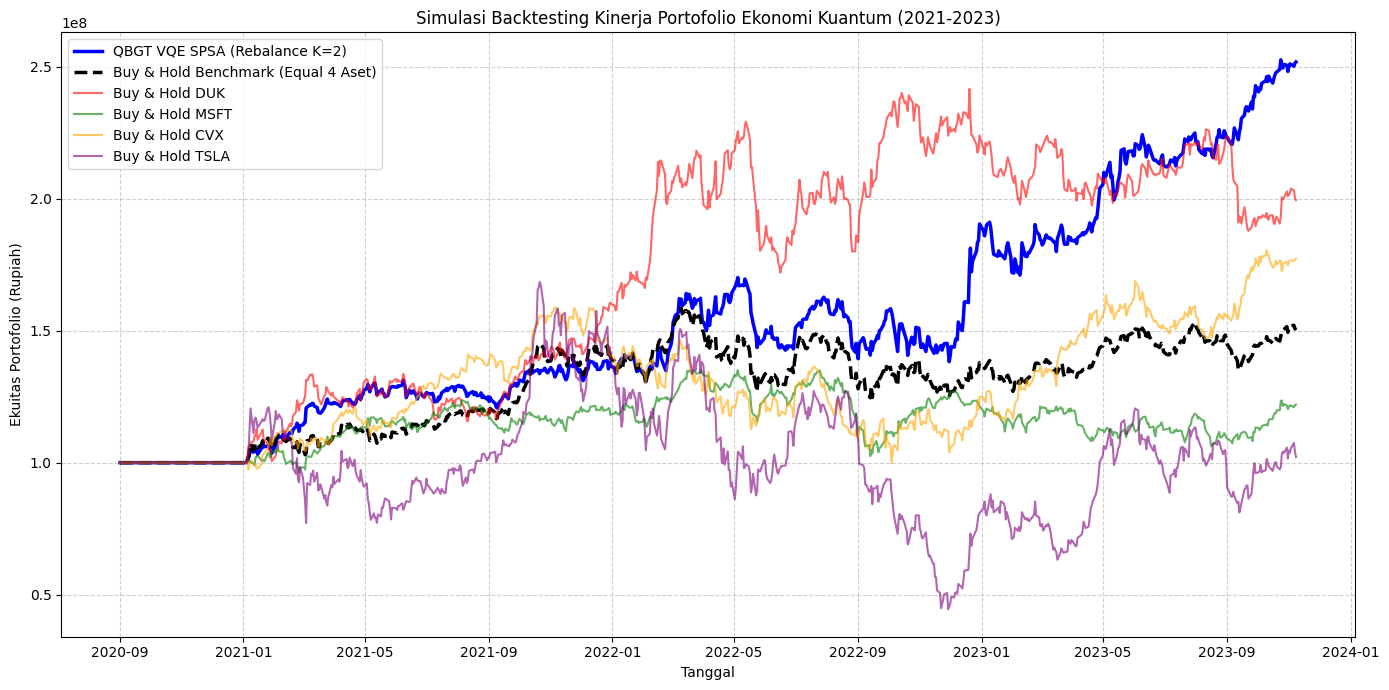

In [ ]:
# === VISUALISASI PERTUMBUHAN PORTOFOLIO ===
plt.figure(figsize=(14, 7))

# Plot VQE Strategy
plt.plot(data_clean.index[:len(value_vqe)], value_vqe, label='QBGT VQE SPSA (Rebalance K=2)', linewidth=2.5, color='blue')

# Plot Buy & Hold All Equal Weights
plt.plot(data_clean.index[:len(value_bench)], value_bench, label='Buy & Hold Benchmark (Equal 4 Aset)', linewidth=2.5, color='black', linestyle='--')

# Plot Individual Buy & Hold
colors = ['red', 'green', 'orange', 'purple']
for j, t in enumerate(tickers):
    plt.plot(data_clean.index[:len(value_assets[t])], value_assets[t], label=f'Buy & Hold {t}', color=colors[j], alpha=0.6)

plt.title('Simulasi Backtesting Kinerja Portofolio Ekonomi Kuantum (2021-2023)')
plt.ylabel('Ekuitas Portofolio (Rupiah)')
plt.xlabel('Tanggal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
